# IMDb Movie Review Sentiment Analysis Using NLP

## Project Overview

### Business Problem
Online platforms generate massive volumes of customer feedback every day, making it difficult for businesses to manually analyze user opinions and identify key drivers of customer satisfaction or dissatisfaction.

For movie production companies, streaming platforms, and entertainment businesses, understanding audience sentiment is critical for evaluating content performance, improving user experience, and making data-driven decisions.

This project aims to leverage Natural Language Processing (NLP) and Machine Learning techniques to automatically analyze movie reviews and classify customer sentiment as positive or negative, enabling scalable and efficient feedback analysis.



### Project Objective
The primary objective of this project is to develop an end-to-end sentiment analysis solution capable of extracting actionable insights from unstructured textual reviews.

The project focuses on:
- Transforming raw textual reviews into structured and analyzable data.
- Identifying common themes and linguistic patterns associated with positive and negative customer experiences.
- Exploring customer sentiment through word frequency analysis, word clouds, and n-gram analysis.
- Applying feature engineering techniques such as Bag of Words and TF-IDF vectorization.
- Building and evaluating machine learning models for automated sentiment classification.
- Comparing different text representation techniques to determine the most effective approach for sentiment prediction.

Ultimately, this solution demonstrates how organizations can utilize customer feedback data to monitor audience perception, improve decision-making, and automate large-scale sentiment monitoring processes.



### Dataset Information
- Source: IMDb Movie Reviews Dataset
- Total Reviews: 50,000
- Features: review, sentiment    
- Target Variable: positive, negative

### Project Workflow
- Data Understanding
- Data Cleaning & Text Preprocessing
- Exploratory Text Analysis
- Lemmatization
- Word Frequency Analysis
- Word Cloud Analysis
- N-Gram Analysis
- Feature Engineering
  1. Bag of Words
  2. TF-IDF
- Sentiment Classification
- Model Evaluation
- Key Findings
- Conclusion


## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Loading Datasets

In [2]:
df = pd.read_csv('IMDB_REVIEW_DATASET.csv')
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


## 3. Dataset Overview

In [3]:
df.shape

(50000, 2)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [5]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [6]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(418)

In [8]:
df = df.drop_duplicates()
df.shape

(49582, 2)

## 4. Text Preprocessing

#### Converting Text to Lowercase

In [9]:
df['review'] = df['review'].str.lower()
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. <br /><br />the...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


#### Removing Whitespaces

In [10]:
df['review'] = df['review'].str.strip()
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. <br /><br />the...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


#### Removing HTML Tags

In [11]:
df['review'] = df['review'].str.replace(r'<.*?>','',regex=True)
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


#### Removing URLs

In [12]:
import re
def remove_url(data):
    data = re.sub(r"https?://\S+|www\.\S+",'',data)
    return data
    

In [13]:
remove_url('to register log on to https://campus.x.in')

'to register log on to '

In [14]:
##code to check if a review contains an URL
df[df['review'].str.contains(r"https?://\S+|www\.\S+",regex = True)].iloc[0].values

array(['mario lewis of the competitive enterprise institute has written a definitive 120-page point-by-point, line-by-line refutation of this mendacious film, which should be titled a convenient lie. the website address where his debunking report, which is titled "a skeptic\'s guide to an inconvenient truth" can be found at is :www.cei.org. a shorter 10-page version can be found at: www.cei.org/pdf/5539.pdf once you read those demolitions, you\'ll realize that alleged "global warming" is no more real or dangerous than the y2k scare of 1999, which gore also endorsed, as he did the pseudo-scientific film the day after tomorrow, which was based on a book written by alleged ufo abductee whitley strieber. as james "the amazing" randi does to psychics, and philip klass does to ufos, and gerald posner does to jfk conspir-idiocy theories, so does mario lewis does to al gore\'s movie and the whole "global warming" scam.',
       'negative'], dtype=object)

In [15]:
#code to remove URLs
df['review'] = df['review'].str.replace(r"https?://\S+|www\.\S+",'',regex = True)

In [16]:
df[df['review'].str.contains(r"https?://\S+|www\.\S+",regex = True)]

,review,sentiment


#### Expanding Contractions

In [17]:
#expanding abbrevations
def remove_abb(data):
    data = re.sub(r"he's", "he is", data)
    data = re.sub(r"there's", "there is", data)
    data = re.sub(r"We're", "We are", data)
    data = re.sub(r"That's", "That is", data)
    data = re.sub(r"won't", "will not", data)
    data = re.sub(r"they're", "they are", data)
    data = re.sub(r"Can't", "Cannot", data)
    data = re.sub(r"wasn't", "was not", data)
    data = re.sub(r"don\x89Ûªt", "do not", data)
    data= re.sub(r"aren't", "are not", data)
    data = re.sub(r"isn't", "is not", data)
    data = re.sub(r"What's", "What is", data)
    data = re.sub(r"haven't", "have not", data)
    data = re.sub(r"hasn't", "has not", data)
    data = re.sub(r"There's", "There is", data)
    data = re.sub(r"He's", "He is", data)
    data = re.sub(r"It's", "It is", data)
    data = re.sub(r"You're", "You are", data)
    data = re.sub(r"I'M", "I am", data)
    data = re.sub(r"shouldn't", "should not", data)
    data = re.sub(r"wouldn't", "would not", data)
    data = re.sub(r"i'm", "I am", data)
    data = re.sub(r"I\x89Ûªm", "I am", data)
    data = re.sub(r"I'm", "I am", data)
    data = re.sub(r"Isn't", "is not", data)
    data = re.sub(r"Here's", "Here is", data)
    data = re.sub(r"you've", "you have", data)
    data = re.sub(r"you\x89Ûªve", "you have", data)
    data = re.sub(r"we're", "we are", data)
    data = re.sub(r"what's", "what is", data)
    data = re.sub(r"couldn't", "could not", data)
    data = re.sub(r"we've", "we have", data)
    data = re.sub(r"it\x89Ûªs", "it is", data)
    data = re.sub(r"doesn\x89Ûªt", "does not", data)
    data = re.sub(r"It\x89Ûªs", "It is", data)
    data = re.sub(r"Here\x89Ûªs", "Here is", data)
    data = re.sub(r"who's", "who is", data)
    data = re.sub(r"I\x89Ûªve", "I have", data)
    data = re.sub(r"y'all", "you all", data)
    data = re.sub(r"can\x89Ûªt", "cannot", data)
    data = re.sub(r"would've", "would have", data)
    data = re.sub(r"it'll", "it will", data)
    data = re.sub(r"we'll", "we will", data)
    data = re.sub(r"wouldn\x89Ûªt", "would not", data)
    data = re.sub(r"We've", "We have", data)
    data = re.sub(r"he'll", "he will", data)
    data = re.sub(r"Y'all", "You all", data)
    data = re.sub(r"Weren't", "Were not", data)
    data = re.sub(r"Didn't", "Did not", data)
    data = re.sub(r"they'll", "they will", data)
    data = re.sub(r"they'd", "they would", data)
    data = re.sub(r"DON'T", "DO NOT", data)
    data = re.sub(r"That\x89Ûªs", "That is", data)
    data = re.sub(r"they've", "they have", data)
    data = re.sub(r"i'd", "I would", data)
    data = re.sub(r"should've", "should have", data)
    data = re.sub(r"You\x89Ûªre", "You are", data)
    data = re.sub(r"where's", "where is", data)
    data = re.sub(r"Don\x89Ûªt", "Do not", data)
    data = re.sub(r"we'd", "we would", data)
    data = re.sub(r"i'll", "I will", data)
    data = re.sub(r"weren't", "were not", data)
    data = re.sub(r"They're", "They are", data)
    data = re.sub(r"Can\x89Ûªt", "Cannot", data)
    data = re.sub(r"you\x89Ûªll", "you will", data)
    data = re.sub(r"I\x89Ûªd", "I would", data)
    data = re.sub(r"let's", "let us", data)
    data = re.sub(r"it's", "it is", data)
    data = re.sub(r"can't", "cannot", data)
    data = re.sub(r"don't", "do not", data)
    data = re.sub(r"you're", "you are", data)
    data = re.sub(r"i've", "I have", data)
    data = re.sub(r"that's", "that is", data)
    data = re.sub(r"i'll", "I will", data)
    data = re.sub(r"doesn't", "does not",data)
    data = re.sub(r"i'd", "I would", data)
    data = re.sub(r"didn't", "did not", data)
    data = re.sub(r"ain't", "am not", data)
    data = re.sub(r"you'll", "you will", data)
    data = re.sub(r"I've", "I have", data)
    data = re.sub(r"Don't", "do not", data)
    data = re.sub(r"I'll", "I will", data)
    data = re.sub(r"I'd", "I would", data)
    data = re.sub(r"Let's", "Let us", data)
    data = re.sub(r"you'd", "You would", data)
    data = re.sub(r"It's", "It is", data)
    data = re.sub(r"Ain't", "am not", data)
    data = re.sub(r"Haven't", "Have not", data)
    data = re.sub(r"Could've", "Could have", data)
    data = re.sub(r"youve", "you have", data)  
    data = re.sub(r"donå«t", "do not", data)
    
    return data

In [18]:
remove_abb("I don't want it and I can't tell you")

'I do not want it and I cannot tell you'

In [19]:
df['review'] = df['review'].apply(remove_abb)
df['review']

0        one of the other reviewers has mentioned that ...
1        a wonderful little production. the filming tec...
2        i thought this was a wonderful way to spend ti...
3        basically there is a family where a little boy...
4        petter mattei's "love in the time of money" is...
                               ...                        
49995    i thought this movie did a down right good job...
49996    bad plot, bad dialogue, bad acting, idiotic di...
49997    i am a catholic taught in parochial elementary...
49998    I am going to have to disagree with the previo...
49999    no one expects the star trek movies to be high...
Name: review, Length: 49582, dtype: object

#### Removing Punctuations

In [20]:
#punctuation
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [21]:
def remove_punctuation(text):
    for i in string.punctuation:
        if i in text:
            text = text.replace(i,'')
    return text

In [22]:
remove_punctuation('Hi! how are you??')

'Hi how are you'

In [23]:
df['review'] = df['review'].apply(remove_punctuation)
df['review'].head()

0    one of the other reviewers has mentioned that ...
1    a wonderful little production the filming tech...
2    i thought this was a wonderful way to spend ti...
3    basically there is a family where a little boy...
4    petter matteis love in the time of money is a ...
Name: review, dtype: object

### Tokenization

In [24]:
import nltk

nltk.download('punkt_tab')
nltk.download('punkt')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\deepak\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\deepak\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [25]:
#tokenization
from nltk.tokenize import word_tokenize

In [26]:
df['tokenized_review'] = df['review'].apply(word_tokenize)

In [27]:
df

,review,sentiment,tokenized_review
0,one of the other reviewers has mentioned that ...,positive,"[one, of, the, other, reviewers, has, mentione..."
1,a wonderful little production the filming tech...,positive,"[a, wonderful, little, production, the, filmin..."
2,i thought this was a wonderful way to spend ti...,positive,"[i, thought, this, was, a, wonderful, way, to,..."
3,basically there is a family where a little boy...,negative,"[basically, there, is, a, family, where, a, li..."
4,petter matteis love in the time of money is a ...,positive,"[petter, matteis, love, in, the, time, of, mon..."
...,...,...,...
49995,i thought this movie did a down right good job...,positive,"[i, thought, this, movie, did, a, down, right,..."
49996,bad plot bad dialogue bad acting idiotic direc...,negative,"[bad, plot, bad, dialogue, bad, acting, idioti..."
49997,i am a catholic taught in parochial elementary...,negative,"[i, am, a, catholic, taught, in, parochial, el..."
49998,I am going to have to disagree with the previo...,negative,"[I, am, going, to, have, to, disagree, with, t..."


### Stopword Removal

In [28]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\deepak\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [29]:
#stop word removal
from nltk.corpus import stopwords

In [30]:
len(stopwords.words('english'))

198

In [31]:
stop_words = stopwords.words('english')

In [32]:
def stopword_removal(text):
    return [word for word in text if word not in stop_words]

In [33]:
df['tokenized_review'] = df['tokenized_review'].apply(stopword_removal)
df

,review,sentiment,tokenized_review
0,one of the other reviewers has mentioned that ...,positive,"[one, reviewers, mentioned, watching, 1, oz, e..."
1,a wonderful little production the filming tech...,positive,"[wonderful, little, production, filming, techn..."
2,i thought this was a wonderful way to spend ti...,positive,"[thought, wonderful, way, spend, time, hot, su..."
3,basically there is a family where a little boy...,negative,"[basically, family, little, boy, jake, thinks,..."
4,petter matteis love in the time of money is a ...,positive,"[petter, matteis, love, time, money, visually,..."
...,...,...,...
49995,i thought this movie did a down right good job...,positive,"[thought, movie, right, good, job, creative, o..."
49996,bad plot bad dialogue bad acting idiotic direc...,negative,"[bad, plot, bad, dialogue, bad, acting, idioti..."
49997,i am a catholic taught in parochial elementary...,negative,"[catholic, taught, parochial, elementary, scho..."
49998,I am going to have to disagree with the previo...,negative,"[I, going, disagree, previous, comment, side, ..."


In [34]:
df['review'] = df['tokenized_review'].apply(lambda x: " ".join(x))
df.head()

,review,sentiment,tokenized_review
0,one reviewers mentioned watching 1 oz episode ...,positive,"[one, reviewers, mentioned, watching, 1, oz, e..."
1,wonderful little production filming technique ...,positive,"[wonderful, little, production, filming, techn..."
2,thought wonderful way spend time hot summer we...,positive,"[thought, wonderful, way, spend, time, hot, su..."
3,basically family little boy jake thinks zombie...,negative,"[basically, family, little, boy, jake, thinks,..."
4,petter matteis love time money visually stunni...,positive,"[petter, matteis, love, time, money, visually,..."


## 5. Exploratory Text Analysis

#### Character & Word Length Analysis

In [35]:
df['character_length'] = df['review'].str.len()
df['word_length'] = df['tokenized_review'].apply(len)
df.head()

,review,sentiment,tokenized_review,character_length,word_length
0,one reviewers mentioned watching 1 oz episode ...,positive,"[one, reviewers, mentioned, watching, 1, oz, e...",1142,166
1,wonderful little production filming technique ...,positive,"[wonderful, little, production, filming, techn...",656,84
2,thought wonderful way spend time hot summer we...,positive,"[thought, wonderful, way, spend, time, hot, su...",592,87
3,basically family little boy jake thinks zombie...,negative,"[basically, family, little, boy, jake, thinks,...",440,64
4,petter matteis love time money visually stunni...,positive,"[petter, matteis, love, time, money, visually,...",863,125


C:\Users\deepak\AppData\Local\Temp\ipykernel_5608\1724139141.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['character_length'])


<Axes: xlabel='character_length', ylabel='Density'>

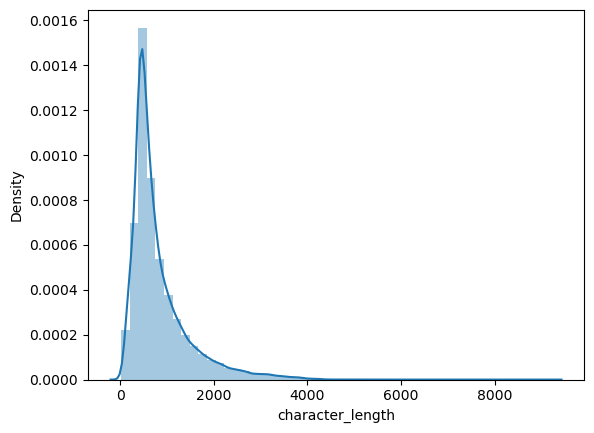

In [36]:
sns.distplot(df['character_length'])

#### Sentiment-wise Length Comparison

In [37]:
df[df['sentiment'] == 'positive']

,review,sentiment,tokenized_review,character_length,word_length
0,one reviewers mentioned watching 1 oz episode ...,positive,"[one, reviewers, mentioned, watching, 1, oz, e...",1142,166
1,wonderful little production filming technique ...,positive,"[wonderful, little, production, filming, techn...",656,84
2,thought wonderful way spend time hot summer we...,positive,"[thought, wonderful, way, spend, time, hot, su...",592,87
4,petter matteis love time money visually stunni...,positive,"[petter, matteis, love, time, money, visually,...",863,125
5,probably alltime favorite movie story selfless...,positive,"[probably, alltime, favorite, movie, story, se...",394,57
...,...,...,...,...,...
49983,loved fan original series always wondered back...,positive,"[loved, fan, original, series, always, wondere...",422,63
49985,imaginary heroes clearly best film year comple...,positive,"[imaginary, heroes, clearly, best, film, year,...",697,101
49989,got one weeks ago love modern light filled tru...,positive,"[got, one, weeks, ago, love, modern, light, fi...",599,88
49992,john garfield plays marine blinded grenade fig...,positive,"[john, garfield, plays, marine, blinded, grena...",633,87


C:\Users\deepak\AppData\Local\Temp\ipykernel_5608\2159983764.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['sentiment'] == 'positive']['character_length'])


<Axes: xlabel='character_length', ylabel='Density'>

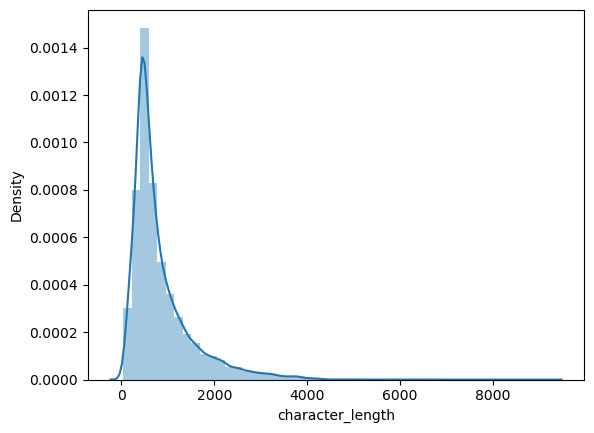

In [38]:
sns.distplot(df[df['sentiment'] == 'positive']['character_length'])

In [39]:
df[df['sentiment'] == 'negative']

,review,sentiment,tokenized_review,character_length,word_length
3,basically family little boy jake thinks zombie...,negative,"[basically, family, little, boy, jake, thinks,...",440,64
7,show amazing fresh innovative idea 70s first a...,negative,"[show, amazing, fresh, innovative, idea, 70s, ...",550,82
8,encouraged positive comments film looking forw...,negative,"[encouraged, positive, comments, film, looking...",414,64
10,phil alien one quirky films humour based aroun...,negative,"[phil, alien, one, quirky, films, humour, base...",369,50
11,saw movie 12 came recall scariest scene big bi...,negative,"[saw, movie, 12, came, recall, scariest, scene...",553,83
...,...,...,...,...,...
49994,typical junk comedythere almost laughs genuine...,negative,"[typical, junk, comedythere, almost, laughs, g...",404,58
49996,bad plot bad dialogue bad acting idiotic direc...,negative,"[bad, plot, bad, dialogue, bad, acting, idioti...",394,55
49997,catholic taught parochial elementary schools n...,negative,"[catholic, taught, parochial, elementary, scho...",819,114
49998,I going disagree previous comment side maltin ...,negative,"[I, going, disagree, previous, comment, side, ...",829,114


C:\Users\deepak\AppData\Local\Temp\ipykernel_5608\1090721372.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['sentiment'] == 'negative']['character_length'])


<Axes: xlabel='character_length', ylabel='Density'>

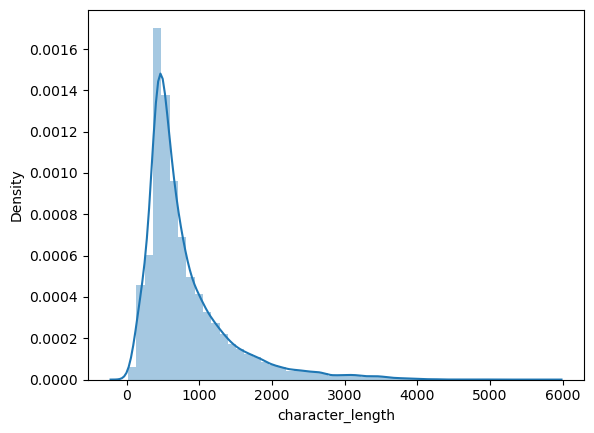

In [40]:
sns.distplot(df[df['sentiment'] == 'negative']['character_length'])

C:\Users\deepak\AppData\Local\Temp\ipykernel_5608\526115980.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['sentiment'] == 'positive']['character_length'])
C:\Users\deepak\AppData\Local\Temp\ipykernel_5608\526115980.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['sentiment'

<Axes: xlabel='character_length', ylabel='Density'>

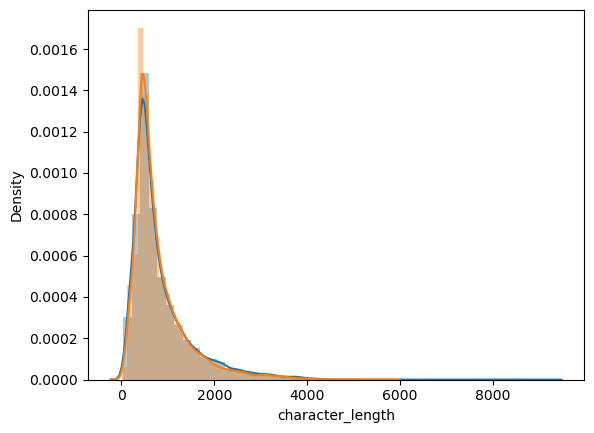

In [41]:
##comparing sentiments on the basis of character length
sns.distplot(df[df['sentiment'] == 'positive']['character_length'])
sns.distplot(df[df['sentiment'] == 'negative']['character_length'])

C:\Users\deepak\AppData\Local\Temp\ipykernel_5608\1296672211.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['sentiment'] == 'positive']['word_length'])
C:\Users\deepak\AppData\Local\Temp\ipykernel_5608\1296672211.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['sentiment'] =

<Axes: xlabel='word_length', ylabel='Density'>

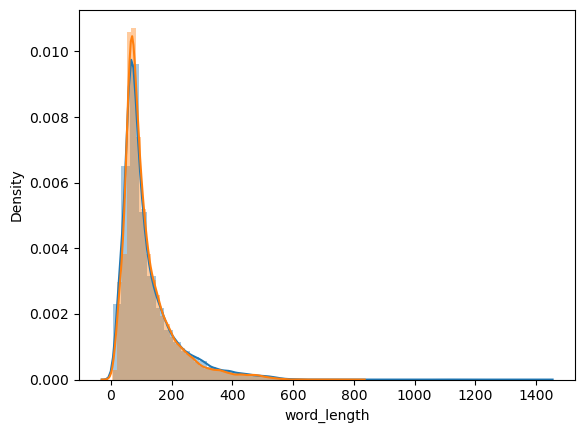

In [42]:
#comparing sentiments on the basis of word length
sns.distplot(df[df['sentiment'] == 'positive']['word_length'])
sns.distplot(df[df['sentiment'] == 'negative']['word_length'])

## 6. Lemmatization
Lemmatization converts words to their dictionary form while preserving semantic meaning. This helps reduce vocabulary size and improves text analysis quality.

In [43]:
import nltk

nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\deepak\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\deepak\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\deepak\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\deepak\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [44]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk import pos_tag

In [45]:
lemmatizer = WordNetLemmatizer()

In [46]:
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [47]:
def lemmatize_tokens(tokens):
    pos_tags = pos_tag(tokens)
    return [
        lemmatizer.lemmatize(word, get_wordnet_pos(pos))
        for word, pos in pos_tags]

In [48]:
df['tokenized_review'] = df['tokenized_review'].apply(lemmatize_tokens)

In [49]:
df['processed_review'] = df['tokenized_review'].apply(lambda x: " ".join(x))

In [50]:
df[['review','processed_review']].head()

,review,processed_review
0,one reviewers mentioned watching 1 oz episode ...,one reviewer mention watch 1 oz episode hook r...
1,wonderful little production filming technique ...,wonderful little production film technique una...
2,thought wonderful way spend time hot summer we...,think wonderful way spend time hot summer week...
3,basically family little boy jake thinks zombie...,basically family little boy jake think zombie ...
4,petter matteis love time money visually stunni...,petter matteis love time money visually stunni...


## 7. Word Frequency Analysis

#### For Posititve Reviews: Top 20 Most Frequent words

In [51]:
positive_df = df[df['sentiment'] == 'positive']

In [52]:
from collections import Counter

In [53]:
positive_words = []
for review in positive_df['tokenized_review']:
    positive_words.extend(review)

positive_freq = Counter(positive_words)

positive_freq_df = pd.DataFrame(
    positive_freq.most_common(20),
    columns=['Word','Frequency'])

In [54]:
positive_freq_df

,Word,Frequency
0,film,48491
1,movie,42897
2,one,26835
3,see,21157
4,make,19889
5,like,18912
6,good,15964
7,get,15819
8,time,15224
9,great,13909


#### For Negative Reviews: Top 20 Most Frequent words

In [55]:
negative_df = df[df['sentiment']=='negative']

In [56]:
negative_words = []
for review in negative_df['tokenized_review']:
    negative_words.extend(review)
negative_freq = Counter(negative_words)

negative_freq_df = pd.DataFrame(negative_freq.most_common(20),columns=['Word','Frequency'])

In [57]:
negative_freq_df

,Word,Frequency
0,movie,55294
1,film,42293
2,one,25415
3,make,23262
4,like,22966
5,bad,19580
6,see,19026
7,get,18971
8,would,17231
9,good,16286


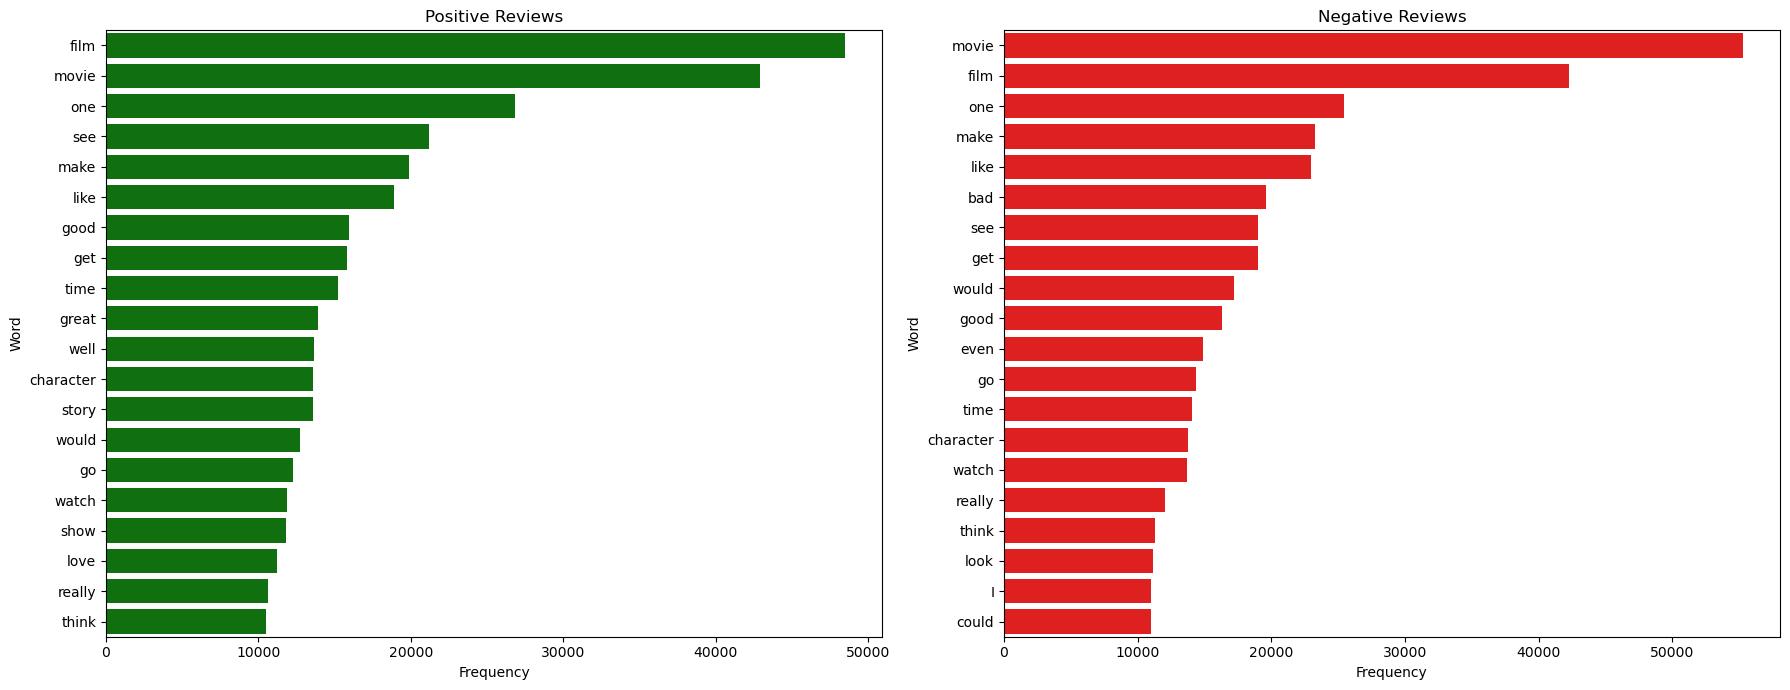

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(18,7))
sns.barplot(
    data=positive_freq_df,
    x='Frequency',
    y='Word',
    ax=axes[0],
    color='green')

axes[0].set_title('Positive Reviews')

sns.barplot(
    data=negative_freq_df,
    x='Frequency',
    y='Word',
    ax=axes[1],
    color='red')
axes[1].set_title('Negative Reviews')

plt.tight_layout()
plt.savefig(
    'Word_Frequency_for_Reviews.png',
    dpi=600,
    bbox_inches='tight')
plt.show()

#### Insight
Word Frequency Analysis was performed to identify the most commonly occurring terms across the IMDb reviews. After preprocessing and lemmatization, word frequencies provide insight into the vocabulary used by users while expressing their opinions about movies.

## 8. Word Cloud Analysis

In [59]:
!pip install wordcloud


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
from wordcloud import WordCloud

#### Word Clouds provide a visual representation of the most frequently occurring terms within positive and negative reviews.

#### For Positive Reviews

In [61]:
all_words = []
for review in positive_df['tokenized_review']:
    all_words.extend(review)
positive_text = " ".join(all_words)

In [62]:
positive_wc = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=100).generate(positive_text)

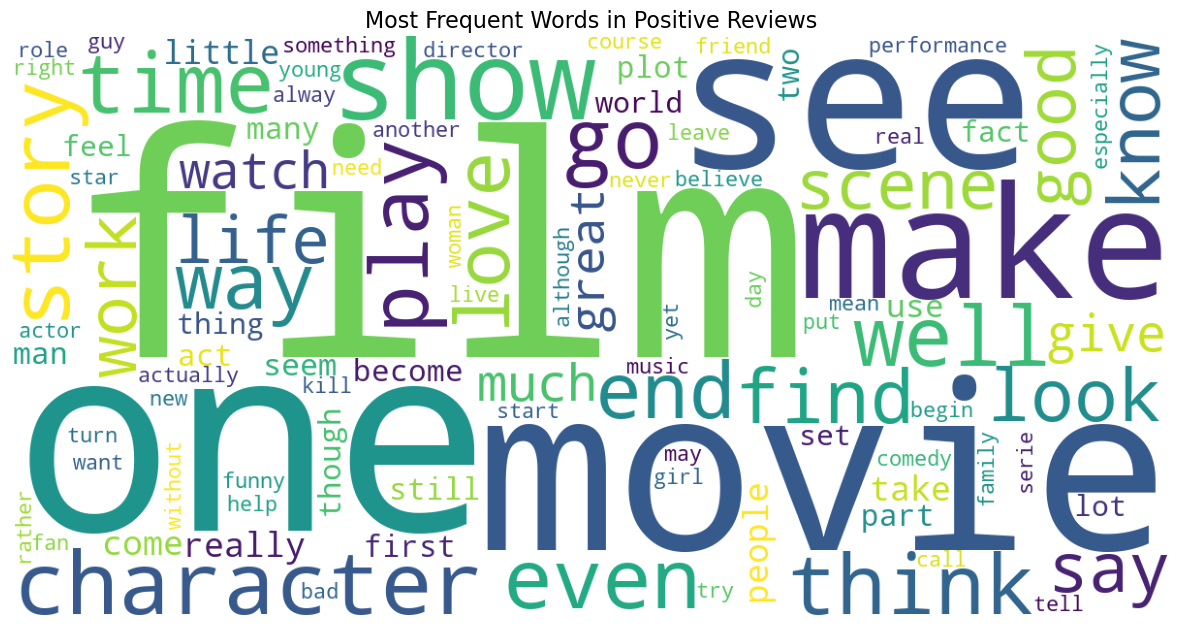

In [63]:
plt.figure(figsize=(15,8))
plt.imshow(positive_wc)
plt.axis('off')
plt.title(
    'Most Frequent Words in Positive Reviews',
    fontsize=16)
plt.savefig(
    'Word_Cloud-Positive_Reviews.png',
    dpi=600,
    bbox_inches='tight')
plt.show()

#### For Negative Reviews

In [64]:
all_words = []
for review in negative_df['tokenized_review']:
    all_words.extend(review)
negative_text = " ".join(all_words)

In [65]:
negative_wc = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=100).generate(negative_text)

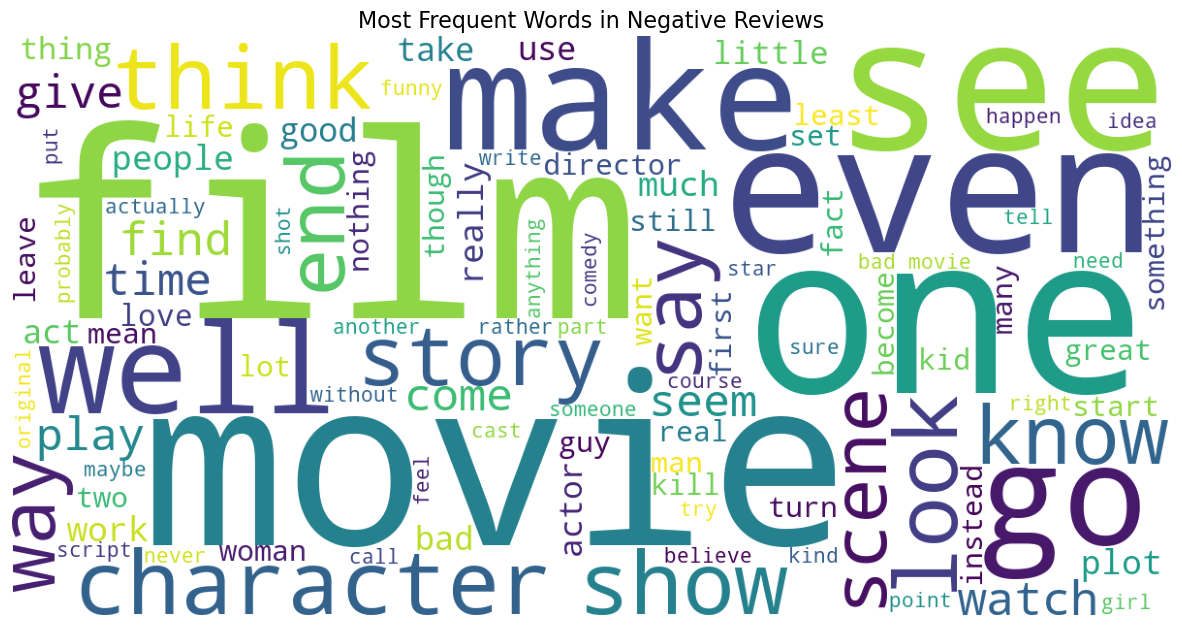

In [66]:
plt.figure(figsize=(15,8))
plt.imshow(negative_wc)
plt.axis('off')
plt.title('Most Frequent Words in Negative Reviews',fontsize=16)
plt.savefig(
    'Word_Cloud-Negative_Reviews.png',
    dpi=600,
    bbox_inches='tight')
plt.show()

#### Insight:
Word Cloud Analysis was performed to visualize the most frequently occurring words in positive and negative movie reviews. Larger words represent higher frequency and provide insights into the themes and vocabulary associated with audience sentiment.

## 9. N-Gram Analysis

In [67]:
from nltk import ngrams

review = ['this', 'movie', 'was', 'very', 'good']
print(list(ngrams(review, 3)))

[('this', 'movie', 'was'), ('movie', 'was', 'very'), ('was', 'very', 'good')]


#### Overall Trigram Analysis

In [68]:
from nltk import ngrams
from collections import Counter

trigram_counts = Counter()
for review in df['tokenized_review']:
    trigram_counts.update(ngrams(review, 3))

print(trigram_counts.most_common(20))

[(('I', 'ever', 'see'), 972), (('movie', 'ever', 'see'), 542), (('bad', 'movie', 'ever'), 487), (('movie', 'I', 'ever'), 355), (('movie', 'ever', 'make'), 341), (('film', 'ever', 'make'), 294), (('movie', 'I', 'see'), 292), (('I', 'would', 'like'), 274), (('one', 'bad', 'movie'), 269), (('film', 'ever', 'see'), 269), (('new', 'york', 'city'), 261), (('film', 'I', 'see'), 258), (('would', 'like', 'see'), 248), (('I', 'would', 'say'), 237), (('bad', 'film', 'ever'), 220), (('bad', 'movie', 'I'), 213), (('world', 'war', 'ii'), 206), (('film', 'I', 'ever'), 191), (('waste', 'time', 'money'), 186), (('make', 'look', 'like'), 180)]


#### Overall Bigram Analysis

In [69]:
from nltk import ngrams
from collections import Counter

bigram_counts = Counter()
for review in df['tokenized_review']:
    bigram_counts.update(ngrams(review, 2))

bigram_counts.most_common(20)

[(('look', 'like'), 3616),
 (('ever', 'see'), 2770),
 (('watch', 'movie'), 2644),
 (('see', 'movie'), 2570),
 (('I', 'would'), 2441),
 (('bad', 'movie'), 2349),
 (('special', 'effect'), 2188),
 (('make', 'movie'), 2180),
 (('I', 'see'), 2145),
 (('movie', 'make'), 1883),
 (('main', 'character'), 1854),
 (('even', 'though'), 1851),
 (('movie', 'like'), 1827),
 (('one', 'best'), 1822),
 (('good', 'movie'), 1693),
 (('film', 'make'), 1680),
 (('see', 'film'), 1669),
 (('year', 'old'), 1658),
 (('make', 'film'), 1610),
 (('movie', 'ever'), 1560)]

#### Positive Review Trigram Analysis

In [70]:
positive_trigram_counts = Counter()
for review in positive_df['tokenized_review']:
    positive_trigram_counts.update(ngrams(review, 3))

print(positive_trigram_counts.most_common(20))

[(('I', 'ever', 'see'), 342), (('new', 'york', 'city'), 186), (('film', 'I', 'see'), 156), (('one', 'best', 'movie'), 153), (('world', 'war', 'ii'), 152), (('film', 'ever', 'make'), 151), (('movie', 'ever', 'see'), 151), (('would', 'like', 'see'), 137), (('one', 'best', 'film'), 136), (('movie', 'I', 'see'), 130), (('base', 'true', 'story'), 122), (('would', 'love', 'see'), 120), (('I', 'would', 'like'), 116), (('first', 'time', 'saw'), 116), (('movie', 'ever', 'make'), 113), (('I', 'would', 'say'), 111), (('best', 'movie', 'ever'), 104), (('well', 'worth', 'watch'), 97), (('first', 'saw', 'movie'), 93), (('see', 'long', 'time'), 88)]


#### Negative Review Trigram Analysis

In [71]:
negative_trigram_counts = Counter()
for review in negative_df['tokenized_review']:
    negative_trigram_counts.update(ngrams(review, 3))

print(negative_trigram_counts.most_common(20))

[(('I', 'ever', 'see'), 630), (('bad', 'movie', 'ever'), 473), (('movie', 'ever', 'see'), 391), (('movie', 'I', 'ever'), 269), (('one', 'bad', 'movie'), 261), (('movie', 'ever', 'make'), 228), (('bad', 'film', 'ever'), 214), (('bad', 'movie', 'I'), 210), (('film', 'ever', 'see'), 198), (('waste', 'time', 'money'), 184), (('movie', 'I', 'see'), 162), (('one', 'bad', 'film'), 160), (('I', 'would', 'like'), 158), (('film', 'ever', 'make'), 143), (('make', 'look', 'like'), 129), (('I', 'would', 'say'), 126), (('film', 'I', 'ever'), 124), (('bad', 'act', 'bad'), 122), (('make', 'good', 'movie'), 114), (('complete', 'waste', 'time'), 111)]


#### Positive Review Bigram Analysis

In [76]:
from nltk import ngrams
from collections import Counter
positive_bigram_counts = Counter()
for review in positive_df['tokenized_review']:
    positive_bigram_counts.update(ngrams(review, 2))
positive_bigram_counts.most_common(20)

[(('one', 'best'), 1596),
 (('see', 'movie'), 1330),
 (('watch', 'movie'), 1109),
 (('I', 'see'), 1066),
 (('I', 'would'), 1063),
 (('ever', 'see'), 1021),
 (('even', 'though'), 1008),
 (('see', 'film'), 987),
 (('look', 'like'), 914),
 (('first', 'time'), 907),
 (('film', 'make'), 868),
 (('make', 'movie'), 851),
 (('new', 'york'), 828),
 (('make', 'film'), 816),
 (('main', 'character'), 810),
 (('special', 'effect'), 784),
 (('movie', 'like'), 779),
 (('great', 'movie'), 774),
 (('year', 'old'), 770),
 (('movie', 'make'), 768)]

### Visualization for Positive Bigram Analysis

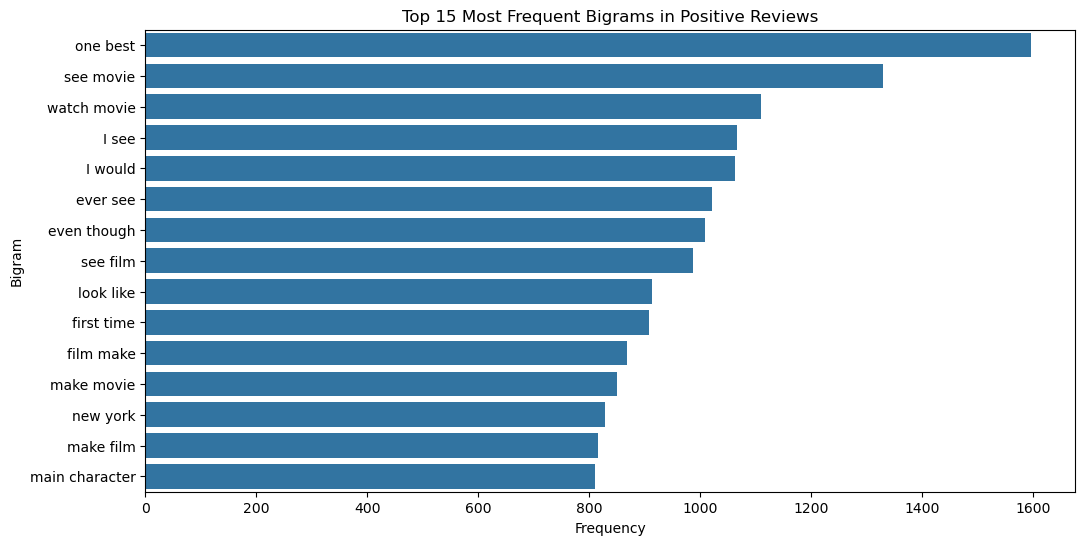

In [78]:
positive_bigram_df = pd.DataFrame(
    positive_bigram_counts.most_common(15),
    columns=['Bigram', 'Frequency'])

positive_bigram_df['Bigram'] = positive_bigram_df['Bigram'].apply(
    lambda x: ' '.join(x))

plt.figure(figsize=(12,6))

sns.barplot(data=positive_bigram_df,x='Frequency',y='Bigram')

plt.title('Top 15 Most Frequent Bigrams in Positive Reviews')
plt.xlabel('Frequency')
plt.ylabel('Bigram')

plt.savefig('positive_bigram_analysis.png',dpi=600,bbox_inches='tight')
plt.show()

#### Negative Review Bigram Analysis

In [79]:
negative_bigram_counts = Counter()
for review in negative_df['tokenized_review']:
    negative_bigram_counts.update(ngrams(review, 2))

negative_bigram_counts.most_common(20)

[(('look', 'like'), 2702),
 (('bad', 'movie'), 2153),
 (('ever', 'see'), 1749),
 (('watch', 'movie'), 1535),
 (('waste', 'time'), 1477),
 (('special', 'effect'), 1404),
 (('I', 'would'), 1378),
 (('make', 'movie'), 1329),
 (('see', 'movie'), 1240),
 (('movie', 'make'), 1115),
 (('I', 'see'), 1079),
 (('movie', 'like'), 1048),
 (('main', 'character'), 1044),
 (('bad', 'film'), 1041),
 (('movie', 'ever'), 1026),
 (('seem', 'like'), 983),
 (('horror', 'movie'), 978),
 (('good', 'movie'), 939),
 (('year', 'old'), 888),
 (('make', 'sense'), 887)]

### Visualization for Negative Bigram Analysis

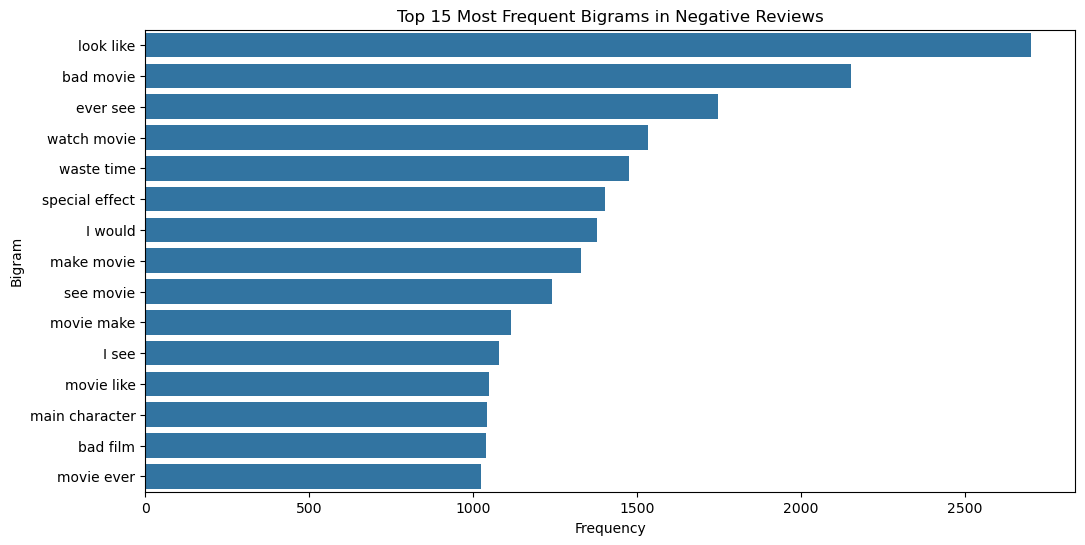

In [80]:
negative_bigram_df = pd.DataFrame(
    negative_bigram_counts.most_common(15),
    columns=['Bigram', 'Frequency'])

negative_bigram_df['Bigram'] = negative_bigram_df['Bigram'].apply(lambda x: ' '.join(x))

plt.figure(figsize=(12,6))

sns.barplot(
    data=negative_bigram_df,
    x='Frequency',
    y='Bigram')

plt.title('Top 15 Most Frequent Bigrams in Negative Reviews')
plt.xlabel('Frequency')
plt.ylabel('Bigram')

plt.savefig('negative_bigram_analysis.png', dpi=600, bbox_inches='tight')

plt.show()

## 10. Feature Engineering

### A. Bag of Words Vectorization
Bag of Words converts text into numerical vectors based on word occurrence frequencies.

#### Applying Bag of Words

In [81]:
from sklearn.feature_extraction.text import CountVectorizer
bow = CountVectorizer(max_features=5000)
X_bow = bow.fit_transform(df['processed_review'])

#### Encode Target Variable

In [82]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y = encoder.fit_transform(df['sentiment'])

In [83]:
print(X_bow.shape)
print(y.shape)

(49582, 5000)
(49582,)


The Bag of Words model transformed 50,000 reviews into a numerical feature matrix containing the 5,000 most frequent terms.

#### Logistic Regression using Bag of Words

In [84]:
from sklearn.model_selection import train_test_split
X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X_bow,
    y,
    test_size=0.2,
    random_state=42)

#### Train Model

In [85]:
from sklearn.linear_model import LogisticRegression
lr_bow = LogisticRegression(max_iter=1000)
lr_bow.fit(X_train_bow, y_train)

LogisticRegression(max_iter=1000)

#### Prediction

In [86]:
y_pred_bow = lr_bow.predict(X_test_bow)

### Model Evaluation

#### Accuracy

In [87]:
from sklearn.metrics import accuracy_score
bow_accuracy = accuracy_score(
    y_test,
    y_pred_bow)
print("BoW Accuracy:", bow_accuracy)

BoW Accuracy: 0.8633659372794191


#### Classification Report

In [88]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_bow))

              precision    recall  f1-score   support

           0       0.87      0.86      0.86      4939
           1       0.86      0.87      0.86      4978

    accuracy                           0.86      9917
   macro avg       0.86      0.86      0.86      9917
weighted avg       0.86      0.86      0.86      9917



#### Confusion Metrix

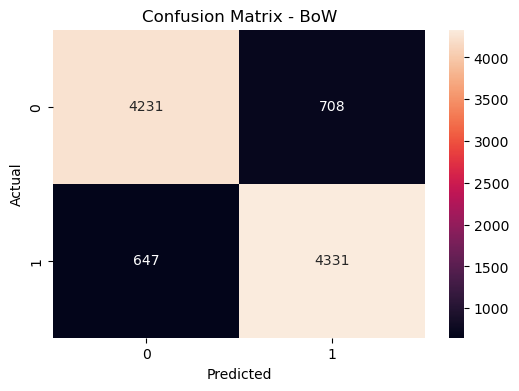

In [89]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred_bow)

plt.figure(figsize=(6,4))

sns.heatmap(cm,annot=True,fmt='d')
plt.title('Confusion Matrix - BoW')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('Confusion_Matrix-BOW.png',
    dpi=600,
    bbox_inches='tight')
plt.show()

#### Insight:
The Bag of Words model achieved an accuracy of 86.34%, demonstrating that simple word frequency representations can effectively capture sentiment patterns within movie reviews. Despite ignoring contextual importance, the model successfully distinguished positive and negative sentiments across a large corpus of reviews.

### B. TF-IDF Vectorization
TF-IDF assigns greater importance to informative words while reducing the influence of commonly occurring words.

In [90]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features=5000)

X_tfidf = tfidf.fit_transform(
    df['processed_review'])

In [91]:
print(X_tfidf.shape)

(49582, 5000)


TF-IDF transformed textual reviews into weighted numerical vectors where sentiment-bearing words receive higher importance than common words.

#### Logistic Regression using TF-IDF

In [92]:
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42)

#### Train Model

In [93]:
lr_tfidf = LogisticRegression(max_iter=1000)

lr_tfidf.fit(X_train_tfidf,y_train)

LogisticRegression(max_iter=1000)

#### Prediction

In [94]:
y_pred_tfidf = lr_tfidf.predict(X_test_tfidf)

### Model Evaluation

#### Accuracy

In [95]:
tfidf_accuracy = accuracy_score(
    y_test,
    y_pred_tfidf)

print("TF-IDF Accuracy:",tfidf_accuracy)

TF-IDF Accuracy: 0.8818190985176969


#### Classification Report

In [96]:
print(classification_report(y_test,y_pred_tfidf))

              precision    recall  f1-score   support

           0       0.89      0.87      0.88      4939
           1       0.87      0.89      0.88      4978

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



#### Confusion Matrix

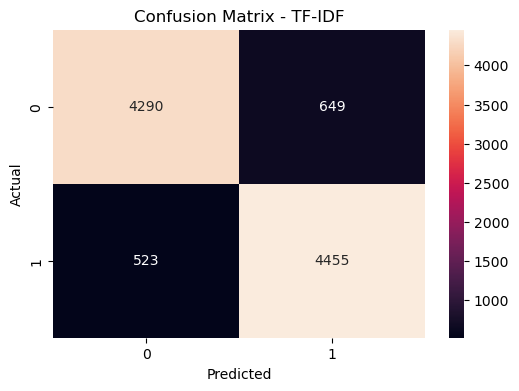

In [97]:
cm = confusion_matrix(y_test,y_pred_tfidf)

plt.figure(figsize=(6,4))

sns.heatmap(cm,annot=True,fmt='d')
plt.title('Confusion Matrix - TF-IDF')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig(
    'Confusion_Matrix_TF-IDF.png',
    dpi=600,
    bbox_inches='tight')
plt.show()

#### Insight:
The TF-IDF model achieved an accuracy of 88.18%, outperforming the Bag of Words approach. By assigning greater importance to sentiment-rich words and reducing the influence of commonly occurring terms, TF-IDF provided a more informative feature representation for sentiment classification.

## Business Value

An automated sentiment analysis system can help organizations:

* Monitor customer satisfaction at scale.
* Identify recurring issues highlighted in customer feedback.
* Track audience perception of products and services.
* Support data-driven business decisions using unstructured text data.
* Reduce manual effort required for review analysis.

In the context of movie reviews, sentiment classification can assist production houses and streaming platforms in understanding audience reactions and evaluating content performance more efficiently.

## 11. Model Comparison

In [98]:
comparison = pd.DataFrame({'Vectorization Technique': ['Bag of Words','TF-IDF'],
    'Accuracy': [bow_accuracy,tfidf_accuracy]})

comparison

,Vectorization Technique,Accuracy
0,Bag of Words,0.863366
1,TF-IDF,0.881819


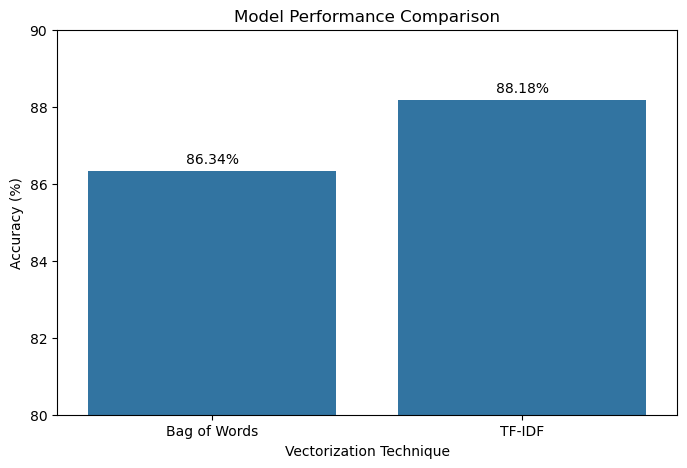

In [100]:
comparison = pd.DataFrame({
    'Vectorization Technique':['Bag of Words','TF-IDF'],
    'Accuracy':[86.34,88.18]})

plt.figure(figsize=(8,5))

ax = sns.barplot(data=comparison, x='Vectorization Technique', y='Accuracy')

plt.title('Model Performance Comparison')
plt.ylabel('Accuracy (%)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3)

plt.ylim(80,90)

plt.savefig('model_comparison.png', dpi=600, bbox_inches='tight')
plt.show()

#### Insight: 
A comparative evaluation of Bag of Words and TF-IDF vectorization techniques revealed that TF-IDF delivered superior predictive performance. The weighted representation of terms enabled the model to focus on discriminative words such as "excellent", "amazing", and "terrible", resulting in improved sentiment classification accuracy.

# Key Findings

* The dataset contains 50,000 balanced movie reviews with equal representation of positive and negative sentiments.
* Text preprocessing significantly improved text quality by removing noise such as HTML tags, URLs, punctuation, and stopwords.
* Word frequency and word cloud analyses revealed distinct vocabulary patterns across positive and negative reviews.
* N-gram analysis highlighted frequently occurring word combinations associated with audience satisfaction and dissatisfaction.
* Bag of Words achieved an accuracy of 86.34%.
* TF-IDF achieved an accuracy of 88.18%.
* TF-IDF outperformed Bag of Words by approximately 1.84 percentage points.
* Logistic Regression proved highly effective for large-scale sentiment classification.


# Conclusion
This project successfully applied Natural Language Processing and Machine Learning techniques to analyze 50,000 IMDb movie reviews and classify audience sentiment.

The workflow included comprehensive text preprocessing, exploratory text analysis, lemmatization, word frequency analysis, word cloud visualization, and n-gram extraction to uncover meaningful linguistic patterns within movie reviews.

Two vectorization techniques—Bag of Words and TF-IDF—were evaluated using Logistic Regression. The TF-IDF model achieved the best performance with an accuracy of 88.18%, outperforming the Bag of Words model, which achieved 86.34%.

The results demonstrate that feature engineering plays a critical role in text classification tasks and that TF-IDF provides a more informative representation of textual data than simple frequency-based approaches.

Overall, this project highlights the effectiveness of NLP techniques for understanding customer opinions and building scalable sentiment analysis solutions from unstructured text data.
